# Librairies à importer

In [1]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
# --- 5. Évaluation des performances (tes indicateurs de succès) ---
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_curve,auc,roc_auc_score,accuracy_score)
# --- 6. Gestion du déséquilibre des classes (très important pour ton projet) ---
from imblearn.over_sampling import SMOTE

## Importation de base

In [2]:
df = pd.read_csv("base_complete_2021.csv", sep=';')
df.head()

,Num_Acc,jour,mois,an,hrmn,lum,com,agg,int,atm,...,etatp,num_veh_y,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202100037733,28,5,2021,14:15,1,CC_97407,2,2,1,...,-1,B01,3,1,0,2,8,1,5,0
1,202100049382,2,3,2021,10:59,1,CC_63113,2,1,1,...,-1,A01,1,10,0,2,1,2,1,0
2,202100038891,20,5,2021,16:50,1,CC_88160,2,2,1,...,-1,A01,1,7,0,2,1,1,1,0
3,202100028616,14,7,2021,19:45,1,CC_80021,2,1,1,...,-1,A01,0,7,0,2,1,15,1,0
4,202100033509,17,6,2021,23:40,3,CC_13214,2,1,1,...,-1,A01,2,7,4,5,1,26,1,0


In [3]:
# Vérification rapide avant de lancer le ML
print(df[['vma', 'an_nais', 'agg', 'catr']].isnull().sum())

vma           0
an_nais    1308
agg           0
catr          0
dtype: int64


In [4]:
# Affiche les 5 premières lignes où an_nais est considéré comme vide
df[df['an_nais'].isnull()].head()

,Num_Acc,jour,mois,an,hrmn,lum,com,agg,int,atm,...,etatp,num_veh_y,senc,catv,obs,obsm,choc,manv,motor,occutc
12,202100021092,3,9,2021,12:51,1,CC_75115,2,1,1,...,-1,Z01,1,7,0,2,8,22,0,0
13,202100017061,23,9,2021,15:40,1,CC_75111,2,3,1,...,-1,Z01,1,32,0,0,0,15,1,0
18,202100005124,2,12,2021,17:45,5,CC_92047,2,1,1,...,-1,B01,0,7,0,2,0,0,0,0
24,202100029859,9,7,2021,19:08,1,CC_92024,2,1,1,...,-1,Z01,2,30,0,2,0,0,0,0
27,202100005052,2,12,2021,06:30,5,CC_69266,2,2,2,...,-1,A01,1,7,0,2,1,26,1,0


In [5]:
df['an_nais']

0        1970.0
1        1979.0
2        1931.0
3        1973.0
4        2002.0
          ...  
56520    1954.0
56521    1963.0
56522    1980.0
56523    1993.0
56524    1937.0
Name: an_nais, Length: 56525, dtype: float64

**nettoyage de *an_nais* :**

In [6]:
# Étape A : Supprimer les NaN (obligatoire pour passer en entier)
df = df.dropna(subset=['an_nais'])

# Étape B : Convertir en type 'int' (entier)
df['an_nais'] = df['an_nais'].astype(int)

# Vérification
df['an_nais'].head()

0    1970
1    1979
2    1931
3    1973
4    2002
Name: an_nais, dtype: int64

## le modèle de Random Forest

In [7]:
df_ml = df.dropna(subset=['an_nais']).copy()
df_ml['target'] = df_ml['grav'].isin([2, 3]).astype(int)
df_ml['age_usager'] = 2026 - df_ml['an_nais']

# Filtrage des âges cohérents
df_ml = df_ml[df_ml['age_usager'].between(0, 110)]

# 2. Préparation des variables (X) et de la cible (y)
var_num = ['vma', 'age_usager', 'nbv'] # On utilise age_usager au lieu de an_nais
var_qual = ['lum', 'agg', 'col', 'catr', 'sexe', 'trajet', 'catv', 'motor']

X = pd.get_dummies(df_ml[var_num + var_qual], drop_first=True).astype(float)
y = df_ml['target']

# 3. Standardisation et Découpage
X[var_num] = StandardScaler().fit_transform(X[var_num])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--- Rapport de Classification (Random Forest) ---
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      8677
           1       0.53      0.40      0.45      2367

    accuracy                           0.80     11044
   macro avg       0.69      0.65      0.66     11044
weighted avg       0.78      0.80      0.78     11044



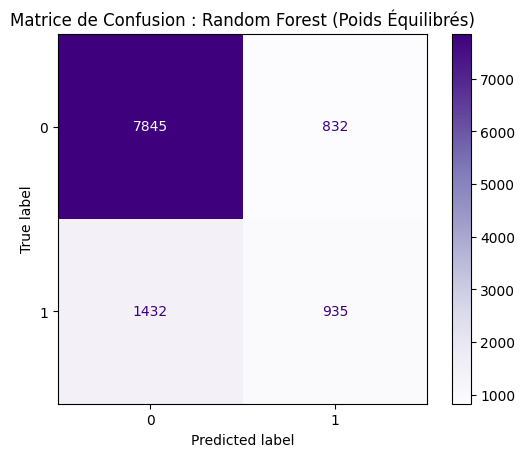

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 3. Entraînement
rf_model.fit(X_train, y_train)

# 4. Prédictions
y_pred_rf = rf_model.predict(X_test)

# 5. Affichage des performances
print("--- Rapport de Classification (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

# 6. Matrice de Confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Purples')
plt.title('Matrice de Confusion : Random Forest (Poids Équilibrés)')
plt.show()

**Commentaire :**

L’utilisation de **poids équilibrés (class weights)** modifie significativement le comportement du modèle par rapport à une approche classique.

- Le modèle identifie **935 accidents graves (vrais positifs)**.  
Cette amélioration est importante car elle permet de détecter davantage de cas graves malgré leur **faible proportion dans la base de données**.

- le modèle génère **832 faux positifs** (accidents légers prédits comme graves). Dans une perspective de **sécurité routière**, cet arbitrage est souvent acceptable : il est préférable de **déclencher une alerte inutile** plutôt que de **manquer un accident potentiellement mortel**.

- Les accidents légers avec **7 845 vrais négatifs**, ce qui montre qu’il conserve une bonne capacité de classification globale.

- La variable **age_usager** est de loin la plus influente (importance > 0.30). Cela confirme que **l’âge de l’usager constitue le principal déterminant de la gravité**, reflétant la vulnérabilité biologique face aux traumatismes.

Les variables tels que : **catv (type de véhicule)**, **col (type de collision)**, **vma (vitesse maximale autorisée)** et **trajet (type de déplacement)** structurent la prédiction dans notre modéle.

Ces facteurs traduisent l’interaction entre **type de véhicule, conditions de choc et vitesse**, qui joue un rôle central dans la gravité des accidents.

Les variables liées à l’environnement routier ont une influence modérée : **nbv (nombre de voies)** et **catr (catégorie de route)** contribuent néanmoins à structurer les décisions du modèle.

Ces variables apparaissent moins discriminantes : **sexe** et **motor (motorisation)** mais leur faible importance indique qu’elles jouent un rôle plus limité dans la prédiction de la gravité des accidents.

## Le SMOTE (Synthetic Minority Over-sampling Technique)

Avant SMOTE : target
0    34703
1     9469
Name: count, dtype: int64
Après SMOTE : target
1    34703
0    34703
Name: count, dtype: int64

--- Rapport de Classification (SMOTE) ---
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      8677
           1       0.50      0.45      0.48      2367

    accuracy                           0.79     11044
   macro avg       0.68      0.66      0.67     11044
weighted avg       0.78      0.79      0.78     11044



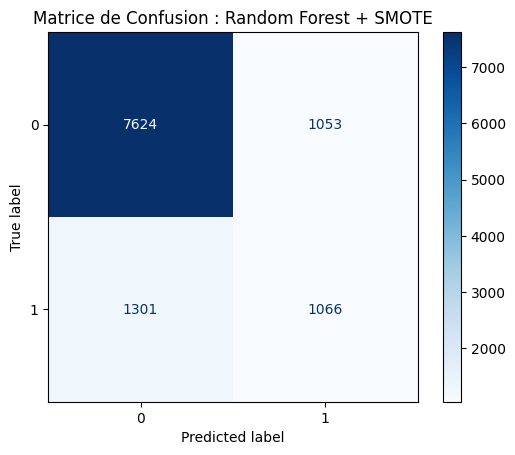

In [26]:
# 1. Initialisation du SMOTE
sm = SMOTE(random_state=42)

# 2. Création du nouveau jeu d'entraînement équilibré (50% / 50%)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts()}")
print(f"Après SMOTE : {y_train_res.value_counts()}")

# 3. Entraînement de la Random Forest sur les données synthétiques
# Note : on retire class_weight='balanced' car les données sont déjà à 50/50
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

# 4. Évaluation sur le jeu de test RÉEL
y_pred_smote = rf_smote.predict(X_test)

print("\n--- Rapport de Classification (SMOTE) ---")
print(classification_report(y_test, y_pred_smote))

# 5. Matrice de Confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Blues')
plt.title('Matrice de Confusion : Random Forest + SMOTE')
plt.show()

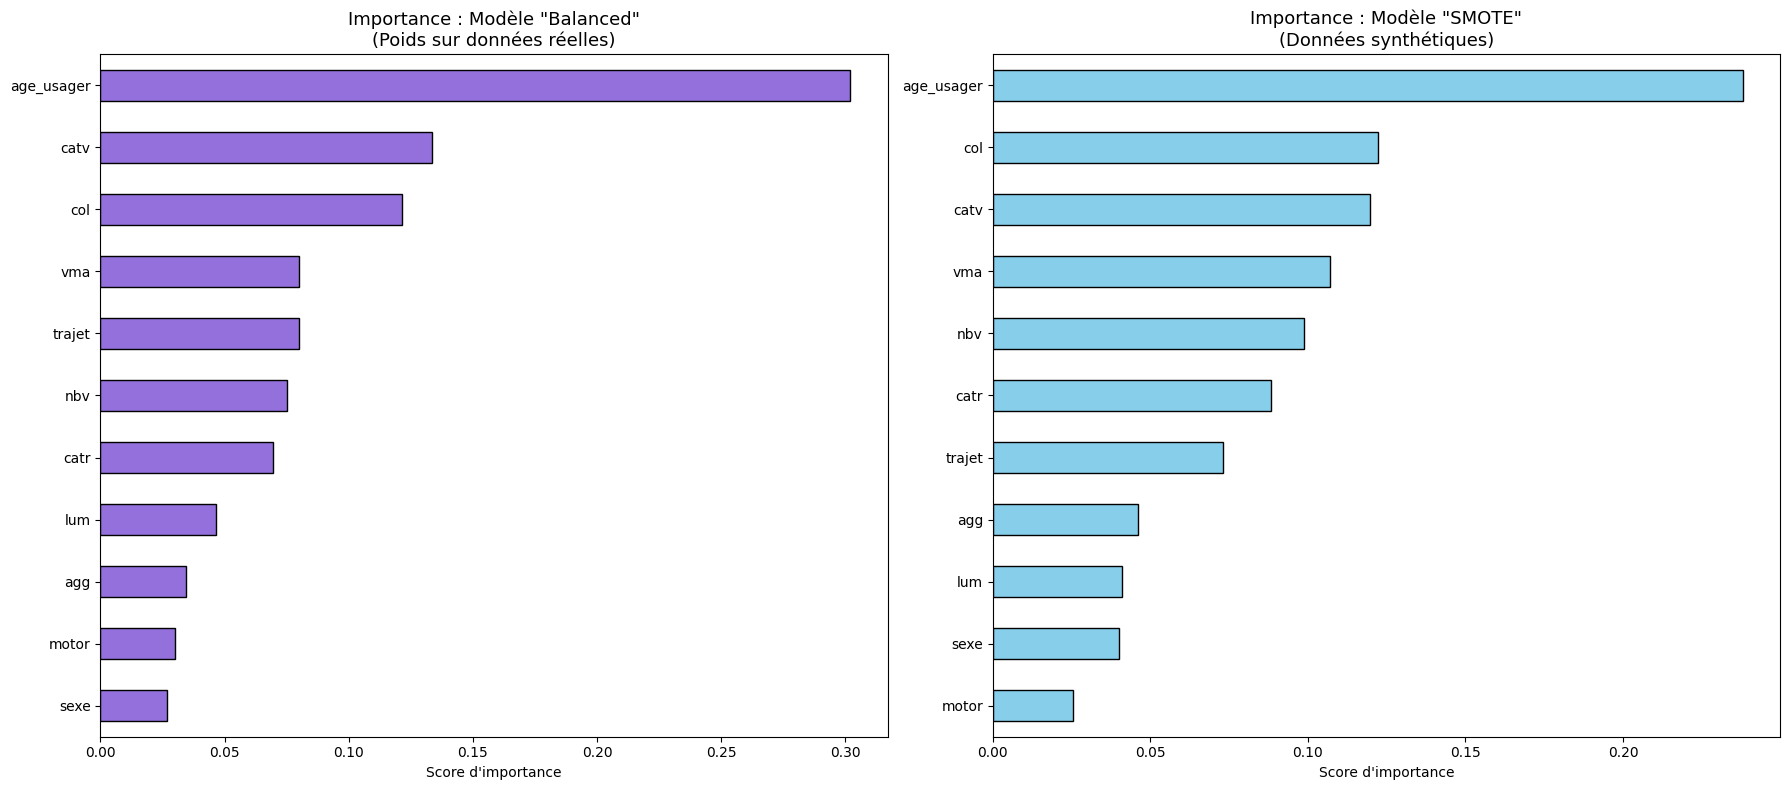

In [30]:
# 1. Extraction des importances pour les deux modèles
# (Assure-toi d'avoir entraîné rf_model avec 'balanced' et rf_smote avec SMOTE avant)
imp_balanced = pd.Series(rf_model.feature_importances_, index=X_train.columns).nlargest(15).sort_values()
imp_smote = pd.Series(rf_smote.feature_importances_, index=X_train.columns).nlargest(15).sort_values()

# 2. Création de la figure avec deux graphiques (1 ligne, 2 colonnes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Graphique 1 : Modèle Balanced
imp_balanced.plot(kind='barh', ax=ax1, color='mediumpurple', edgecolor='black')
ax1.set_title('Importance : Modèle "Balanced"\n(Poids sur données réelles)', fontsize=13)
ax1.set_xlabel('Score d\'importance')

# Graphique 2 : Modèle SMOTE
imp_smote.plot(kind='barh', ax=ax2, color='skyblue', edgecolor='black')
ax2.set_title('Importance : Modèle "SMOTE"\n(Données synthétiques)', fontsize=13)
ax2.set_xlabel('Score d\'importance')

plt.tight_layout()
plt.show()

**Commentaire :**

Avant l'application de **SMOTE**, le jeu de données présentait un fort déséquilibre :
**34 703 accidents légers (classe 0)**
**9 469 accidents graves (classe 1)**

Après l'application de **SMOTE**, les deux classes sont **parfaitement équilibrées avec 34 703 observations chacune**.  
Cette étape est essentielle car elle permet de **réduire le biais du modèle en faveur de la classe majoritaire**, améliorant ainsi la capacité à détecter les accidents graves.

- Comparaison des performances : Balanced vs SMOTE

| Indicateur (Classe 1 - Grave) | Modèle Balanced | Modèle SMOTE |
|--------------------------------|----------------|--------------|
| Précision | 0.53 | 0.50 |
| Recall (Rappel) | 0.40 | 0.45 |
| F1-score | 0.45 | 0.48 |
| Vrais positifs (graves détectés) | 935 | 1 066 |

 
Le modèle basé sur **SMOTE** détecte **1 066 accidents graves**, contre **935 pour le modèle Balanced**.  

**recall de 0.45** montre qu’il capture une proportion plus importante des accidents réellement graves.

**Précision globale :**  
L’**accuracy reste stable autour de 79–80 %** pour les deux modèles, ce qui indique que l'amélioration du rappel ne dégrade pas significativement la performance globale.

L'analyse des variables montre une **forte convergence entre les deux modèles**, ce qui confirme la robustesse des facteurs explicatifs.

La variable **age_usager** est largement dominante avec une importance proche de **0.30** dans les deux modèles.  
Cela indique que **l’âge constitue le principal prédicteur de la gravité des accidents**.

Les variables suivantes arrivent systématiquement en tête après l’âge : **catv** : catégorie de véhicule et **col** : type de collision. Ces variables capturent la **dynamique du choc et la vulnérabilité liée au véhicule**.

Les variables liées à l’environnement routier jouent également un rôle notable : **vma** : vitesse maximale autorisée, **nbv** : nombre de voies et **catr** : catégorie de route influencent la probabilité qu’un accident devienne grave.

Certaines variables apparaissent moins discriminantes : **sexe**, **motor** : type de motorisation et **agg** : agglomération ont un **impact limité dans la prédiction de la gravité des accidents**.